In [ ]:
# !pip install xgboost joblib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.rcParams["figure.figsize"] = (6,4)

# === Cargar PaySim ===
df = pd.read_csv("Data/PS_20174392719_1491204439457_log.csv")
print(df.shape)
df.head()


(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# 2.1 Dummies para el tipo de transacción
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# 2.2 Features diseñadas para detectar cosas raras
df['amount_ratio']  = df['amount'] / (df['oldbalanceOrg'] + 1)
df['delta_balance'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_error'] = (df['oldbalanceOrg'] + df['amount']) - df['newbalanceOrig']

# 2.3 Eliminar columnas que no usamos
cols_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=cols_drop)

# 2.4 Separar features y etiqueta 
X = df.drop(columns=['isFraud'])
y = df['isFraud']

print("Fraudes totales:", y.sum())
print("Proporción de fraude:", y.mean())


Fraudes totales: 8213
Proporción de fraude: 0.001290820448180152


In [26]:
# Primero: train+temp y test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Luego: train y valid dentro del train_val
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 0.25 de 0.8 = 0.2 total → 60% train, 20% valid, 20% test
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)


Train: (3817572, 13) Valid: (1272524, 13) Test: (1272524, 13)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)


In [28]:
mask_normal_train = (y_train == 0)
X_train_normal = X_train_scaled[mask_normal_train]

print("Transacciones normales en train:", X_train_normal.shape[0])


Transacciones normales en train: 3812644


In [29]:
param_grid = {
    "contamination": [0.005, 0.01, 0.02, 0.03, 0.05],
    "n_estimators": [200, 400]
}

results = []

best_model = None
best_score = -np.inf   # aquí guardamos el mejor AUC-F1 combinado
best_params = None

for cont in param_grid["contamination"]:
    for n_est in param_grid["n_estimators"]:
        print(f"\n=== Entrenando IsolationForest(cont={cont}, n_estimators={n_est}) ===")
        
        iso = IsolationForest(
            n_estimators=n_est,
            contamination=cont,
            max_samples='auto',
            random_state=42,
            n_jobs=-1
        )
        iso.fit(X_train_normal)
        
        # Scores en valid (score alto = más anómalo)
        scores_valid = -iso.decision_function(X_valid_scaled)
        
        # Threshold estándar según sklearn (predict) para ver un baseline
        y_pred_raw = iso.predict(X_valid_scaled)   # 1 normal / -1 anómalo
        y_pred = np.where(y_pred_raw == -1, 1, 0)  # 1 = fraude
        
        report = classification_report(y_valid, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_valid, y_pred)
        auc = roc_auc_score(y_valid, scores_valid)
        
        recall_fraud = report['1']['recall']
        prec_fraud   = report['1']['precision']
        f1_fraud     = report['1']['f1-score']
        
        # Score para elegir modelo: combinación de AUC y recall de fraude
        combined_score = auc + recall_fraud
        
        results.append({
            "contamination": cont,
            "n_estimators": n_est,
            "auc": auc,
            "recall_fraud": recall_fraud,
            "precision_fraud": prec_fraud,
            "f1_fraud": f1_fraud,
            "combined_score": combined_score
        })
        
        print("AUC:", round(auc,4),
              " | Recall fraude:", round(recall_fraud,4),
              " | Precision fraude:", round(prec_fraud,4),
              " | F1 fraude:", round(f1_fraud,4))
        
        if combined_score > best_score:
            best_score = combined_score
            best_model = iso
            best_params = (cont, n_est)

print("\n>>> Mejores parámetros encontrados:", best_params)



=== Entrenando IsolationForest(cont=0.005, n_estimators=200) ===
AUC: 0.8909  | Recall fraude: 0.1821  | Precision fraude: 0.0442  | F1 fraude: 0.0712

=== Entrenando IsolationForest(cont=0.005, n_estimators=400) ===
AUC: 0.8978  | Recall fraude: 0.2113  | Precision fraude: 0.0512  | F1 fraude: 0.0824

=== Entrenando IsolationForest(cont=0.01, n_estimators=200) ===
AUC: 0.8909  | Recall fraude: 0.2826  | Precision fraude: 0.0355  | F1 fraude: 0.063

=== Entrenando IsolationForest(cont=0.01, n_estimators=400) ===
AUC: 0.8978  | Recall fraude: 0.3179  | Precision fraude: 0.0398  | F1 fraude: 0.0707

=== Entrenando IsolationForest(cont=0.02, n_estimators=200) ===
AUC: 0.8909  | Recall fraude: 0.3928  | Precision fraude: 0.0251  | F1 fraude: 0.0473

=== Entrenando IsolationForest(cont=0.02, n_estimators=400) ===
AUC: 0.8978  | Recall fraude: 0.4184  | Precision fraude: 0.0266  | F1 fraude: 0.05

=== Entrenando IsolationForest(cont=0.03, n_estimators=200) ===
AUC: 0.8909  | Recall fraude: 

In [30]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="combined_score", ascending=False).head(10)


,contamination,n_estimators,auc,recall_fraud,precision_fraud,f1_fraud,combined_score
9,0.050,400,0.897834,0.585871,0.015011,0.029273,1.483705
8,0.050,200,0.890850,0.564555,0.014478,0.028232,1.455406
7,0.030,400,0.897834,0.491474,0.020901,0.040096,1.389308
6,0.030,200,0.890850,0.470767,0.020039,0.038442,1.361618
5,0.020,400,0.897834,0.418392,0.026614,0.050046,1.316226
4,0.020,200,0.890850,0.392814,0.025144,0.047263,1.283664
3,0.010,400,0.897834,0.317905,0.039753,0.070669,1.215739
2,0.010,200,0.890850,0.282582,0.035477,0.063039,1.173433
1,0.005,400,0.897834,0.211328,0.051210,0.082442,1.109162
0,0.005,200,0.890850,0.182095,0.044218,0.071157,1.072945


In [31]:
# Usamos el mejor modelo ya entrenado: best_model
# Scores en VALID
scores_valid = -best_model.decision_function(X_valid_scaled)

# Vamos a probar varios percentiles como umbral
percentiles = [90, 92, 94, 95, 96, 97, 98, 99]

threshold_results = []
best_thr = None
best_thr_score = -np.inf

for p in percentiles:
    thr = np.percentile(scores_valid, p)
    y_pred_thr = (scores_valid >= thr).astype(int)  # 1 = fraude si score >= thr
    
    report = classification_report(y_valid, y_pred_thr, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_valid, y_pred_thr)
    auc = roc_auc_score(y_valid, scores_valid)
    
    recall_fraud = report['1']['recall']
    prec_fraud   = report['1']['precision']
    f1_fraud     = report['1']['f1-score']
    
    # aquí quiero priorizar recall, pero sin matar la precisión
    thr_score = recall_fraud + 0.3 * prec_fraud
    
    threshold_results.append({
        "percentile": p,
        "threshold": thr,
        "auc": auc,
        "recall_fraud": recall_fraud,
        "precision_fraud": prec_fraud,
        "f1_fraud": f1_fraud,
        "score": thr_score
    })
    
    print(f"Perc {p}: thr={thr:.4f} | Recall fraude={recall_fraud:.4f} | Prec fraude={prec_fraud:.4f} | F1={f1_fraud:.4f}")

    if thr_score > best_thr_score:
        best_thr_score = thr_score
        best_thr = thr

print("\n>>> Mejor umbral elegido:", best_thr)
threshold_df = pd.DataFrame(threshold_results).sort_values(by="score", ascending=False)
threshold_df.head(10)


Perc 90: thr=-0.0431 | Recall fraude=0.6973 | Prec fraude=0.0090 | F1=0.0178
Perc 92: thr=-0.0292 | Recall fraude=0.6596 | Prec fraude=0.0106 | F1=0.0209
Perc 94: thr=-0.0111 | Recall fraude=0.6163 | Prec fraude=0.0133 | F1=0.0260
Perc 95: thr=0.0004 | Recall fraude=0.5840 | Prec fraude=0.0151 | F1=0.0294
Perc 96: thr=0.0143 | Recall fraude=0.5390 | Prec fraude=0.0174 | F1=0.0337
Perc 97: thr=0.0316 | Recall fraude=0.4896 | Prec fraude=0.0211 | F1=0.0404
Perc 98: thr=0.0522 | Recall fraude=0.4160 | Prec fraude=0.0268 | F1=0.0504
Perc 99: thr=0.0850 | Recall fraude=0.3124 | Prec fraude=0.0403 | F1=0.0714

>>> Mejor umbral elegido: -0.04312182409867079


,percentile,threshold,auc,recall_fraud,precision_fraud,f1_fraud,score
0,90,-0.043122,0.897834,0.697320,0.008998,0.017766,0.700020
1,92,-0.029249,0.897834,0.659562,0.010638,0.020939,0.662753
2,94,-0.011058,0.897834,0.616322,0.013254,0.025951,0.620298
3,95,0.000402,0.897834,0.584044,0.015072,0.029386,0.588566
4,96,0.014300,0.897834,0.538977,0.017387,0.033687,0.544193
5,97,0.031621,0.897834,0.489647,0.021060,0.040384,0.495965
6,98,0.052244,0.897834,0.415956,0.026836,0.050419,0.424007
7,99,0.084996,0.897834,0.312424,0.040311,0.071409,0.324517


=== CLASIFICATION REPORT (TEST) ===
              precision    recall  f1-score   support

           0     0.9996    0.9004    0.9474   1270881
           1     0.0090    0.6975    0.0177      1643

    accuracy                         0.9002   1272524
   macro avg     0.5043    0.7990    0.4826   1272524
weighted avg     0.9983    0.9002    0.9462   1272524

Matriz de confusión (test):
 [[1144346  126535]
 [    497    1146]]


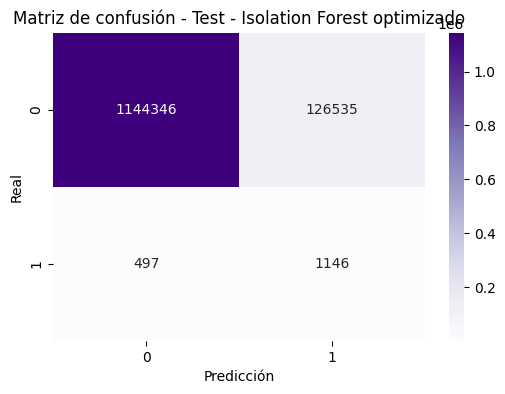

ROC-AUC (test): 0.9045


In [32]:
# Scores en TEST
scores_test = -best_model.decision_function(X_test_scaled)

# Predicciones usando el mejor umbral
y_pred_test = (scores_test >= best_thr).astype(int)

print("=== CLASIFICATION REPORT (TEST) ===")
print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))

cm_test = confusion_matrix(y_test, y_pred_test)
print("Matriz de confusión (test):\n", cm_test)

plt.figure()
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples')
plt.title("Matriz de confusión - Test - Isolation Forest optimizado")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

auc_test = roc_auc_score(y_test, scores_test)
print("ROC-AUC (test):", round(auc_test,4))


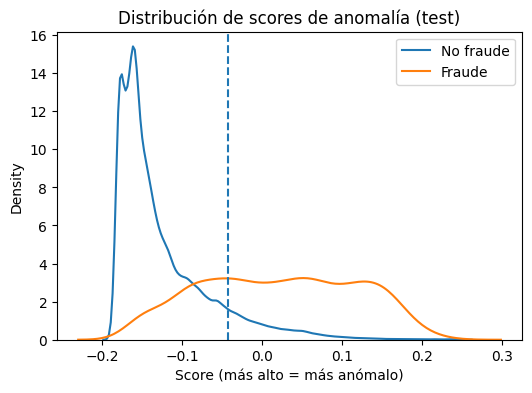

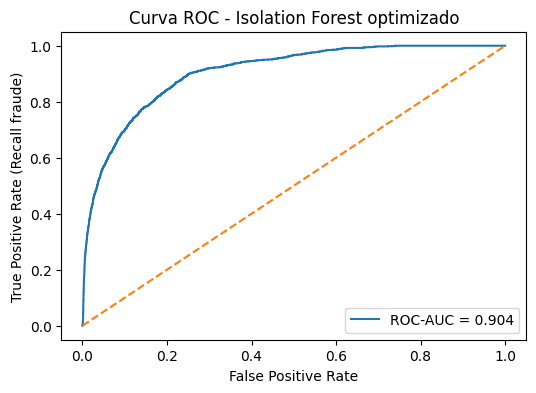

In [33]:
# Distribución de los scores de anomalía
plt.figure()
sns.kdeplot(scores_test[y_test==0], label="No fraude")
sns.kdeplot(scores_test[y_test==1], label="Fraude")
plt.axvline(best_thr, linestyle="--")
plt.title("Distribución de scores de anomalía (test)")
plt.xlabel("Score (más alto = más anómalo)")
plt.legend()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, scores_test)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_test:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall fraude)")
plt.title("Curva ROC - Isolation Forest optimizado")
plt.legend()
plt.show()


In [34]:
bundle = {
    "model": best_model,
    "scaler": scaler,
    "feature_cols": X.columns.tolist(),
    "threshold": best_thr
}

joblib.dump(bundle, "modelo_isoforest_paysim_optimo.pkl")
print("Modelo guardado como 'modelo_isoforest_paysim_optimo.pkl'")


Modelo guardado como 'modelo_isoforest_paysim_optimo.pkl'


In [35]:
scores_test = -best_model.decision_function(X_test_scaled)
y_pred_test = (scores_test >= best_thr).astype(int)

print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))
cm_test = confusion_matrix(y_test, y_pred_test)
print(cm_test)


              precision    recall  f1-score   support

           0     0.9996    0.9004    0.9474   1270881
           1     0.0090    0.6975    0.0177      1643

    accuracy                         0.9002   1272524
   macro avg     0.5043    0.7990    0.4826   1272524
weighted avg     0.9983    0.9002    0.9462   1272524

[[1144346  126535]
 [    497    1146]]


XGBoost con SMOTE

In [36]:
from sklearn.model_selection import train_test_split
import numpy as np

# Partimos del df que ya preprocesaste:
# - sin nameOrig, nameDest, isFlaggedFraud
# - con dummies de 'type'
# - con amount_ratio, delta_balance, balance_error

fraud_df  = df[df['isFraud'] == 1]
normal_df = df[df['isFraud'] == 0]

print("Fraudes:", fraud_df.shape, "Normales:", normal_df.shape)

# Tomamos TODOS los fraudes + una muestra de normales
normal_sample = normal_df.sample(n=200_000, random_state=42)  # puedes subir a 300k si tu PC aguanta

supervised_df = pd.concat([fraud_df, normal_sample], axis=0)
supervised_df = supervised_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

X_sup = supervised_df.drop(columns=['isFraud'])
y_sup = supervised_df['isFraud']

print("Shape supervisado:", X_sup.shape, "Fraude proportion:", y_sup.mean())


Fraudes: (8213, 14) Normales: (6354407, 14)
Shape supervisado: (208213, 13) Fraude proportion: 0.039445183538011554


In [37]:
X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(
    X_sup, y_sup,
    test_size=0.25,
    random_state=42,
    stratify=y_sup
)

print("Train:", X_train_sup.shape, "Test:", X_test_sup.shape)
print("Distribución train:", y_train_sup.value_counts(normalize=True))


Train: (156159, 13) Test: (52054, 13)
Distribución train: isFraud
0    0.960553
1    0.039447
Name: proportion, dtype: float64


In [42]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(
    sampling_strategy=0.5,  # aprox 1 fraude por cada 2 normales
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_sup, y_train_sup)

print("Antes SMOTE:", y_train_sup.value_counts())
print("Después SMOTE:", y_train_sm.value_counts())


Antes SMOTE: isFraud
0    149999
1      6160
Name: count, dtype: int64
Después SMOTE: isFraud
0    149999
1     74999
Name: count, dtype: int64


In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train_sm, y_train_sm)

# Predicción en test supervisado (sin SMOTE)
y_pred_sup = xgb.predict(X_test_sup)
y_prob_sup = xgb.predict_proba(X_test_sup)[:, 1]

print("=== XGBOOST + SMOTE (TEST SUPERVISADO) ===")
print(classification_report(y_test_sup, y_pred_sup, digits=4))

cm_sup = confusion_matrix(y_test_sup, y_pred_sup)
print("Matriz de confusión:\n", cm_sup)

auc_sup = roc_auc_score(y_test_sup, y_prob_sup)
print("ROC-AUC:", auc_sup)


=== XGBOOST + SMOTE (TEST SUPERVISADO) ===
              precision    recall  f1-score   support

           0     0.9999    0.9997    0.9998     50001
           1     0.9932    0.9971    0.9951      2053

    accuracy                         0.9996     52054
   macro avg     0.9965    0.9984    0.9975     52054
weighted avg     0.9996    0.9996    0.9996     52054

Matriz de confusión:
 [[49987    14]
 [    6  2047]]
ROC-AUC: 0.9997221195371514


In [44]:
import joblib

joblib.dump(xgb, "modelo_xgb_fraude.pkl")
print("Modelo XGBoost guardado como 'modelo_xgb_fraude.pkl'")


Modelo XGBoost guardado como 'modelo_xgb_fraude.pkl'
